In [5]:
import requests
import pandas as pd
import time

headers = {"User-Agent": "Mozilla/5.0 heb-analysis"}

comments_data = []

session = requests.Session()
session.headers.update(headers)

for post_id in df["id"].head(100):
    url = f"https://www.reddit.com/r/HEB/comments/{post_id}.json"

    try:
        response = session.get(url, timeout=10)

        if response.status_code != 200:
            print(f"Skipping {post_id}: status {response.status_code}")
            time.sleep(1.5)
            continue

        data = response.json()

        if len(data) < 2:
            time.sleep(1.5)
            continue

        comment_listing = data[1]["data"]["children"]

        for item in comment_listing:
            if item.get("kind") != "t1":
                continue

            c = item.get("data", {})
            comments_data.append({
                "post_id": post_id,
                "comment_id": c.get("id"),
                "comment_body": c.get("body"),
                "comment_score": c.get("score")
            })

    except requests.exceptions.ReadTimeout:
        print(f"Timeout on post {post_id}, skipping...")
    except requests.exceptions.RequestException as e:
        print(f"Request failed for post {post_id}: {e}")

    time.sleep(1.5)

comments_df = pd.DataFrame(comments_data)

print("Total posts:", len(df))
print("Total comments:", len(comments_df))

df.head(), comments_df.head()

Total posts: 129
Total comments: 1074


(        id                                              title  \
 0  1i8zlw2                [Meta] Rules, Automations, Feedback   
 1  1s8tlkp      $15 for a brisket sandwich. Are they serious?   
 2  1s8yq38                             Something ain't right!   
 3  1s8d12a  I was a walmart night stocked for 5 years and ...   
 4  1s8mgpw                               Chocolate Croissants   
 
                                                 text  score  comments  
 0  Hi everyone, \n\n I’d like to take a moment to...     20         4  
 1        Honestly how many of these are thrown away?    837       350  
 2            The XL limes versus normal sized limes      23        12  
 3                                                       213        16  
 4  In the past, my HEB had chocolate croissants t...     31        20  ,
    post_id comment_id                                       comment_body  \
 0  1i8zlw2    neyfwn3    what is old ruffl crop shrug mean on my receipt   
 1  1i8zl

In [7]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)        # remove links
    text = re.sub(r"[^a-z\s]", "", text)       # remove punctuation/numbers
    text = re.sub(r"\s+", " ", text).strip()   # clean extra spaces
    return text

# standardize column name
comments_df["text"] = comments_df["comment_body"]

# create cleaned text column
comments_df["clean_text"] = comments_df["text"].apply(clean_text)

# preview
comments_df[["text", "clean_text"]].head()

,text,clean_text
0,what is old ruffl crop shrug mean on my receipt,what is old ruffl crop shrug mean on my receipt
1,"Not sure that you can do anything, or if you'd...",not sure that you can do anything or if youd e...
2,Reminder to follow our content guidelines. No ...,reminder to follow our content guidelines no p...
3,dayum they charging more than Bucees,dayum they charging more than bucees
4,Nah there actually free if you eat it in the s...,nah there actually free if you eat it in the s...


In [8]:
comments_df[["text", "clean_text"]].head()

,text,clean_text
0,what is old ruffl crop shrug mean on my receipt,what is old ruffl crop shrug mean on my receipt
1,"Not sure that you can do anything, or if you'd...",not sure that you can do anything or if youd e...
2,Reminder to follow our content guidelines. No ...,reminder to follow our content guidelines no p...
3,dayum they charging more than Bucees,dayum they charging more than bucees
4,Nah there actually free if you eat it in the s...,nah there actually free if you eat it in the s...


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=1000
)

X = vectorizer.fit_transform(comments_df["clean_text"])

In [12]:
from sklearn.cluster import KMeans

k = 6 

kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)

comments_df["cluster"] = kmeans.labels_

In [17]:
terms = vectorizer.get_feature_names_out()

with open("filter_terms.txt") as f:
    FILTER_TERMS = [line.strip().lower() for line in f if line.strip()]

def is_bad_word(word):
    word = word.lower()
    return any(root in word for root in FILTER_TERMS)

for i in range(k):
    print(f"\nCluster {i}:")
    
    center = kmeans.cluster_centers_[i]
    
    top_indices = center.argsort()[::-1][:30]
    
    clean_terms = []
    for ind in top_indices:
        word = terms[ind]
        if not is_bad_word(word):
            clean_terms.append(word)
        if len(clean_terms) == 10:
            break
    
    print(clean_terms)


Cluster 0:
['heb', 'like', 'brand', 'looks', 'walmart', 'work', 'better', 'days', 'just', 'way']

Cluster 1:
['just', 'dont', 'time', 'like', 'want', 'job', 'work', 'day', 'got', 'im']

Cluster 2:
['removed', 'work', 'brisket', 'lol', 'like', 'yes', 'hours', 'chips', 'day', 'im']

Cluster 3:
['store', 'thats', 'way', 'time', 'hours', 'ask', 'manager', 'partners', 'let', 'yes']

Cluster 4:
['good', 'really', 'thing', 'brisket', 'pickings', 'theyre', 'probably', 'bbq', 'pretty', 'sandwich']

Cluster 5:
['dont', 'people', 'buy', 'know', 'time', 'think', 'work', 'like', 'need', 'heb']


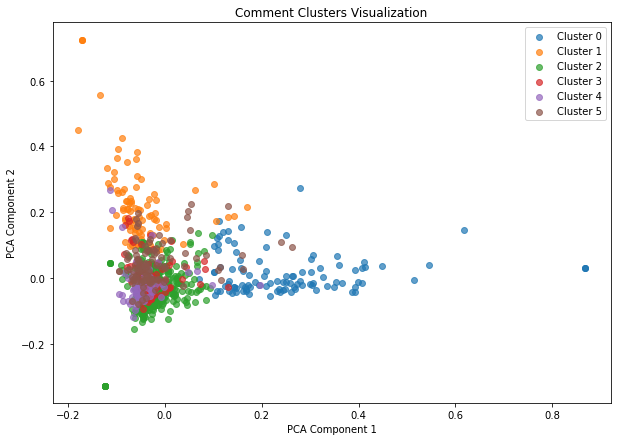

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# reduce sparse TF-IDF matrix to 2D
pca = PCA(n_components=2, random_state=42)
X_dense = X.toarray()
X_2d = pca.fit_transform(X_dense)

# save coordinates
comments_df["pca1"] = X_2d[:, 0]
comments_df["pca2"] = X_2d[:, 1]

# plot
plt.figure(figsize=(10, 7))

for cluster_num in sorted(comments_df["cluster"].unique()):
    cluster_data = comments_df[comments_df["cluster"] == cluster_num]
    plt.scatter(
        cluster_data["pca1"],
        cluster_data["pca2"],
        label=f"Cluster {cluster_num}",
        alpha=0.7
    )

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Comment Clusters Visualization")
plt.legend()
plt.show()